***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.2 基础校准流程](9_2_calibration_workflow.ipynb)
    * 下一节： [9.4 自校准实战](9_4_self_calibration.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.3 连续谱基础成像：从 dirty image 到 restored image

校准之后，最常见的下一步就是成像。实践里我们通常关心四个对象：

- 真实天空模型；
- 由采样函数卷积后的 dirty image；
- 与采样函数对应的 PSF；
- 去卷积并恢复后的 clean / restored image。

这一节用一个完全可运行的二维直接傅里叶实验，把这条链路压缩成最小原型。它不能替代 `tclean` 之类的工业级实现，但足以帮助我们把“图像里看到的结构”与“采样和去卷积造成的结构”分开。


***


In [2]:
def baseline_pairs(nant):
    return [(p, q) for p in range(nant) for q in range(p + 1, nant)]


def uv_tracks(ant_xy_m, hour_angle_h, dec_deg, wavelength_m=0.214):
    pairs = baseline_pairs(len(ant_xy_m))
    hour_angle_rad = np.deg2rad(15.0 * hour_angle_h)
    dec = np.deg2rad(dec_deg)
    u = []
    v = []
    for ha in hour_angle_rad:
        for p, q in pairs:
            dx = (ant_xy_m[q, 0] - ant_xy_m[p, 0]) / wavelength_m
            dy = (ant_xy_m[q, 1] - ant_xy_m[p, 1]) / wavelength_m
            uu = dx * np.sin(ha) + dy * np.cos(ha)
            vv = -dx * np.sin(dec) * np.cos(ha) + dy * np.sin(dec) * np.sin(ha)
            u.extend([uu, -uu])
            v.extend([vv, -vv])
    return np.array(u), np.array(v)


def make_sky(npix=64, cell=0.005):
    coords = (np.arange(npix) - npix // 2) * cell
    l_grid, m_grid = np.meshgrid(coords, coords)
    sky = np.zeros((npix, npix))
    sources = [
        (1.0, 0.00, 0.00),
        (0.26, 0.04, -0.025),
        (0.18, -0.055, 0.035),
    ]
    for flux, l_src, m_src in sources:
        idx = np.argmin(np.abs(coords - l_src))
        idy = np.argmin(np.abs(coords - m_src))
        sky[idy, idx] += flux
    return coords, l_grid, m_grid, sky


def vis_from_sky(u, v, l_grid, m_grid, sky):
    l_flat = l_grid.ravel()
    m_flat = m_grid.ravel()
    sky_flat = sky.ravel()
    phase = np.exp(-2j * np.pi * (u[:, None] * l_flat[None, :] + v[:, None] * m_flat[None, :]))
    return phase @ sky_flat


def direct_image(u, v, vis, l_grid, m_grid, weights=None):
    if weights is None:
        weights = np.ones_like(u)
    l_flat = l_grid.ravel()
    m_flat = m_grid.ravel()
    phase = np.exp(2j * np.pi * (u[:, None] * l_flat[None, :] + v[:, None] * m_flat[None, :]))
    image = (weights * vis) @ phase / np.sum(weights)
    return np.real(image.reshape(l_grid.shape))


def hogbom_clean(dirty, psf, gain=0.12, niter=120, threshold=0.03):
    residual = dirty.copy()
    model = np.zeros_like(dirty)
    psf_peak = np.unravel_index(np.argmax(np.abs(psf)), psf.shape)

    for _ in range(niter):
        peak_idx = np.unravel_index(np.argmax(np.abs(residual)), residual.shape)
        peak_val = residual[peak_idx]
        if np.abs(peak_val) < threshold:
            break
        model[peak_idx] += gain * peak_val
        shifted = np.roll(np.roll(psf, peak_idx[0] - psf_peak[0], axis=0), peak_idx[1] - psf_peak[1], axis=1)
        residual -= gain * peak_val * shifted
    return model, residual


def gaussian_kernel(npix, sigma_pix=1.2):
    coords = np.arange(npix) - npix // 2
    x, y = np.meshgrid(coords, coords)
    kernel = np.exp(-(x**2 + y**2) / (2.0 * sigma_pix**2))
    kernel /= kernel.sum()
    return np.fft.ifftshift(kernel)


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(kernel)
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


ant_xy_m = np.array(
    [
        [0.0, 0.0],
        [42.0, 16.0],
        [116.0, -26.0],
        [214.0, 40.0],
        [342.0, -38.0],
        [468.0, 12.0],
    ]
)
times_h = np.linspace(-4.0, 4.0, 18)
u, v = uv_tracks(ant_xy_m, times_h, dec_deg=42.0, wavelength_m=0.214)

coords, l_grid, m_grid, true_sky = make_sky(npix=64, cell=0.005)
model_vis = vis_from_sky(u, v, l_grid, m_grid, true_sky)
noisy_vis = model_vis + 0.03 * (
    RNG.normal(size=model_vis.size) + 1j * RNG.normal(size=model_vis.size)
)

dirty_image = direct_image(u, v, noisy_vis, l_grid, m_grid)
psf = direct_image(u, v, np.ones_like(noisy_vis), l_grid, m_grid)
clean_components, residual = hogbom_clean(dirty_image, psf, gain=0.12, niter=130, threshold=0.03)
restore_kernel = gaussian_kernel(true_sky.shape[0], sigma_pix=1.25)
restored = fft_convolve_same(clean_components, restore_kernel) + residual

def off_source_rms(image):
    mask = np.ones_like(image, dtype=bool)
    for ly, lx in [(32, 32), (27, 40), (39, 21)]:
        mask[max(0, ly - 4):ly + 5, max(0, lx - 4):lx + 5] = False
    return np.sqrt(np.mean(image[mask] ** 2))


dirty_rms = off_source_rms(dirty_image)
restored_rms = off_source_rms(restored)
dirty_dr = dirty_image.max() / dirty_rms
restored_dr = restored.max() / restored_rms


### 9.3.1 Dirty image、PSF 与 restored image 的最小原型

下图把成像的四个核心对象放在一起。请特别注意两点：

- dirty image 中的条纹和负瓣，并不一定属于天空本身；
- restored image 的改善来自去卷积与恢复波束，而不是“凭空制造信息”。


Dirty image 离源 RMS = 0.0436
Restored image 离源 RMS = 0.0086


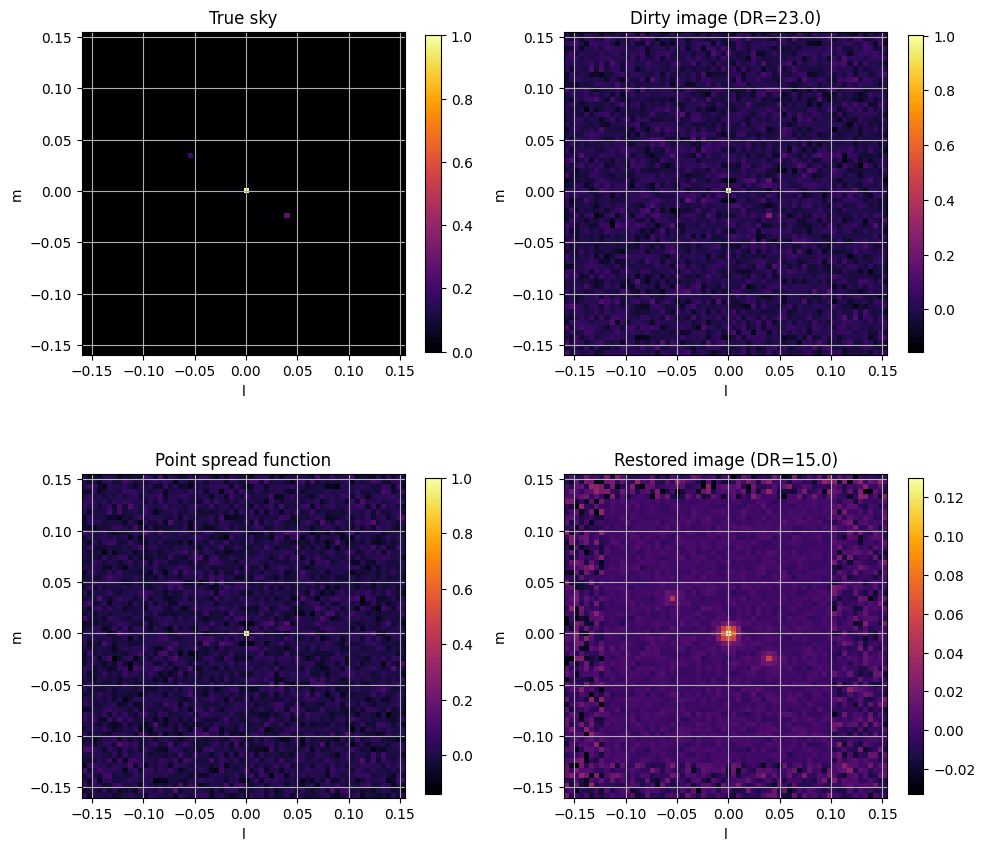

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

images = [
    (true_sky, "True sky"),
    (dirty_image, f"Dirty image (DR={dirty_dr:.1f})"),
    (psf, "Point spread function"),
    (restored, f"Restored image (DR={restored_dr:.1f})"),
]

for ax, (image, title) in zip(axes.ravel(), images):
    im = ax.imshow(
        image,
        origin="lower",
        extent=[coords[0], coords[-1], coords[0], coords[-1]],
        cmap="inferno",
    )
    ax.set_xlabel("l")
    ax.set_ylabel("m")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
print(f"Dirty image 离源 RMS = {dirty_rms:.4f}")
print(f"Restored image 离源 RMS = {restored_rms:.4f}")


这个例子里 restored image 的动态范围明显高于 dirty image，但 residual 依然存在。这正是实践中最常见的状态：成像并不是“按一次按钮就到真相”，而是一个不断平衡采样、权重、mask、迭代次数和校准质量的过程。


### 9.3.2 与 `tclean` 等成像任务的对应

若把这个 notebook 映射到真实软件，通常需要特别关心以下参数：

- `cell`：像素大小；
- `imsize`：图像尺寸；
- `weighting` 与 `robust`：分辨率和灵敏度权衡；
- `niter` / `threshold`：去卷积停止条件；
- `mask`：哪些区域允许 CLEAN 继续挖掘分量；
- `pbcor`：是否做主波束校正。

从工作流角度看，只有在校准残差已经足够小的情况下，调这些成像参数才真正有意义。否则，图像里最显著的结构可能仍然是校准错误，而不是天体结构。
